# 統計的仮説検定

ある仮説が正しいかどうかを統計的に検証する手法。

というのがよくある説明だが、実際は、ある結果が偶然起こったものかそうでないかを検証する手法。有意でないという仮定の下でその結果が起こる確率（p値）を計算し、その確率が十分に小さい場合は有意であると結論づける。この時のしきい値を有意水準と呼び、これは事前に決めておく。大体5%、厳しめに見るときは1%がよく使われる。

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

## 二項検定

二項分布を用いた検定。

### 例題1

> AさんとBさんでじゃんけんを100回行ったらAさんが65勝した。この偏りは有意かどうか。

有意水準は5%とする。

確率$\theta$のベルヌーイ試行を$n$回行った時の成功回数$k$は以下の二項分布に従う。

$$
P(k) = \binom{n}{k} \theta^k (1-\theta)^{n-k}
$$

例題における、有意でないという仮定の下、つまり$n=100, \theta = 0.5$のとき、片方が65勝以上する確率を求める。これがp値となる。

$$
\begin{align}

p
&= 2 \cdot P(k \geq 65) \\
&= 2 \cdot \sum_{k=65}^{100} \binom{100}{k} 0.5^k (1-0.5)^{100-k}

\end{align}
$$

今回は偏りを見ているので、AさんBさんのいずれかが65勝以上する確率を求める。二項分布は左右対称なので、片方が65勝以上する確率を求めて、それを2倍する。この用に両方の確率を求める検定を両側検定と呼ぶ。反対に片方の確率だけを求める検定は片側検定と呼ぶ。

以下の図における赤い部分の面積を求めるという意味になる。

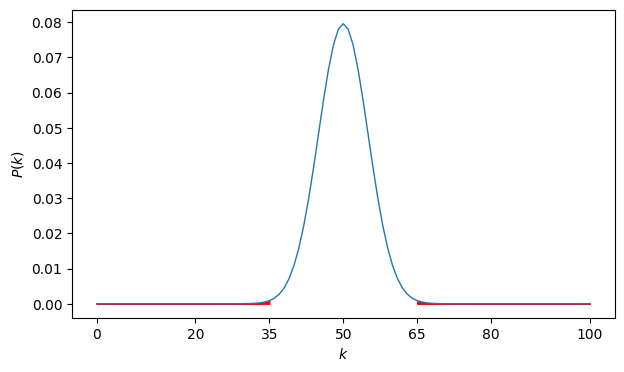

In [2]:
theta = 0.5
n = 100
k_ = np.arange(0, n+1)
p = stats.binom.pmf(k_, n, theta)
plt.figure(figsize=(7, 4))
plt.plot(k_, p, linewidth=1)
plt.fill_between(k_, p, where=(k_ >= 65), color="red")
plt.fill_between(k_, p, where=(k_ <= 35), color="red")
plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.xticks([0, 20, 35, 50, 65, 80, 100]);

実際に計算するとこうなる。

In [3]:
p = 2 * (1 - stats.binom.cdf(64, 100, 0.5))
# p = 2 * stats.binom.cdf(35, 100, 0.5) # これでもいい
print(p)

0.0035176417229700885


0.3%ということで、5%を下回ったので有意であると結論づける。AさんがBさんの癖を見抜いているなど、何らかの理由があると考えられる。

### 例題2

> プロ野球の交流戦では、通算でパ・リーグが1369勝1217敗78分で勝ち越している。この結果から、パ・リーグはセ・リーグより強いと言えるかどうか。

In [4]:
n = 1369 + 1217
k = 1369
p = 2 * (1 - stats.binom.cdf(k-1, n, 0.5))
print(p)

0.0029769530584686787


引き分けは除外して考えた。p=0.2%ということで、偶然ではなく、有意にパ・リーグの方が強いと言える。